In [1]:
from module import *

# Info

In [2]:
table_info("hourly_calories")

nrows: 24084
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            5 non-null      float64
 1   ActivityHour  5 non-null      str    
 2   Calories      5 non-null      int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 252.0 bytes


,Id,ActivityHour,Calories
0,1.503960e+09,3/12/2016 12:00:00 AM,48
1,1.503960e+09,3/12/2016 1:00:00 AM,48
2,1.503960e+09,3/12/2016 2:00:00 AM,48
3,1.503960e+09,3/12/2016 3:00:00 AM,48
4,1.503960e+09,3/12/2016 4:00:00 AM,48


In [3]:
table_info("hourly_intensity")

nrows: 24084
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                5 non-null      float64
 1   ActivityHour      5 non-null      str    
 2   TotalIntensity    5 non-null      int64  
 3   AverageIntensity  5 non-null      float64
dtypes: float64(2), int64(1), str(1)
memory usage: 292.0 bytes


,Id,ActivityHour,TotalIntensity,AverageIntensity
0,1.503960e+09,3/12/2016 12:00:00 AM,0,0.0
1,1.503960e+09,3/12/2016 1:00:00 AM,0,0.0
2,1.503960e+09,3/12/2016 2:00:00 AM,0,0.0
3,1.503960e+09,3/12/2016 3:00:00 AM,0,0.0
4,1.503960e+09,3/12/2016 4:00:00 AM,0,0.0


In [2]:
table_info("hourly_steps")

nrows: 24084
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            5 non-null      float64
 1   ActivityHour  5 non-null      str    
 2   StepTotal     5 non-null      int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 252.0 bytes


,Id,ActivityHour,StepTotal
0,1.503960e+09,3/12/2016 12:00:00 AM,0
1,1.503960e+09,3/12/2016 1:00:00 AM,0
2,1.503960e+09,3/12/2016 2:00:00 AM,0
3,1.503960e+09,3/12/2016 3:00:00 AM,0
4,1.503960e+09,3/12/2016 4:00:00 AM,0


# Data

In [38]:
df = pd.read_sql("""
                 SELECT *
                 FROM hourly_calories
                 NATURAL JOIN hourly_intensity
                 NATURAL JOIN hourly_steps
                 """, conn)
df['Id'] = df['Id'].astype(int)
df['ActivityHour'] = pd.to_datetime(df['ActivityHour'], format=DATE_FMT)
df

,Id,ActivityHour,Calories,TotalIntensity,AverageIntensity,StepTotal
0,1503960366,2016-03-12 00:00:00,48,0,0.000000,0
1,1503960366,2016-03-12 01:00:00,48,0,0.000000,0
2,1503960366,2016-03-12 02:00:00,48,0,0.000000,0
3,1503960366,2016-03-12 03:00:00,48,0,0.000000,0
4,1503960366,2016-03-12 04:00:00,48,0,0.000000,0
...,...,...,...,...,...,...
24079,8877689391,2016-04-12 04:00:00,73,0,0.000000,0
24080,8877689391,2016-04-12 05:00:00,73,0,0.000000,0
24081,8877689391,2016-04-12 06:00:00,96,7,0.116667,209
24082,8877689391,2016-04-12 07:00:00,169,26,0.433333,964


In [39]:
melt = df.melt(
    id_vars=['Id','ActivityHour'],
    value_vars=['Calories', 'TotalIntensity', 'AverageIntensity', 'StepTotal']
)
melt

,Id,ActivityHour,variable,value
0,1503960366,2016-03-12 00:00:00,Calories,48.0
1,1503960366,2016-03-12 01:00:00,Calories,48.0
2,1503960366,2016-03-12 02:00:00,Calories,48.0
3,1503960366,2016-03-12 03:00:00,Calories,48.0
4,1503960366,2016-03-12 04:00:00,Calories,48.0
...,...,...,...,...
96331,8877689391,2016-04-12 04:00:00,StepTotal,0.0
96332,8877689391,2016-04-12 05:00:00,StepTotal,0.0
96333,8877689391,2016-04-12 06:00:00,StepTotal,209.0
96334,8877689391,2016-04-12 07:00:00,StepTotal,964.0


In [36]:
stats = melt.groupby(['variable','ActivityHour'])['value'].describe().reset_index()
stats

,variable,ActivityHour,count,mean,std,min,25%,50%,75%,max
0,AverageIntensity,2016-03-12 00:00:00,33.0,0.049495,0.116031,0.0,0.0,0.0,0.016667,0.566667
1,AverageIntensity,2016-03-12 01:00:00,33.0,0.023737,0.050005,0.0,0.0,0.0,0.033333,0.200000
2,AverageIntensity,2016-03-12 02:00:00,33.0,0.014646,0.039695,0.0,0.0,0.0,0.000000,0.166667
3,AverageIntensity,2016-03-12 03:00:00,33.0,0.008586,0.032307,0.0,0.0,0.0,0.000000,0.183333
4,AverageIntensity,2016-03-12 04:00:00,33.0,0.008081,0.032840,0.0,0.0,0.0,0.000000,0.183333
...,...,...,...,...,...,...,...,...,...,...
3015,TotalIntensity,2016-04-12 06:00:00,17.0,5.647059,8.724543,0.0,0.0,0.0,7.000000,28.000000
3016,TotalIntensity,2016-04-12 07:00:00,15.0,22.266667,27.768087,0.0,2.5,14.0,28.000000,109.000000
3017,TotalIntensity,2016-04-12 08:00:00,12.0,11.000000,13.066265,0.0,2.5,9.5,13.250000,48.000000
3018,TotalIntensity,2016-04-12 09:00:00,11.0,15.727273,22.249004,0.0,0.0,13.0,16.000000,76.000000


In [41]:
stats_melt = stats.melt(
                id_vars=['variable','ActivityHour'],
                value_vars=['min','25%','50%','75%','max'][::-1],
                var_name='stat',
                value_name='value'
)
stats_melt

,variable,ActivityHour,stat,value
0,AverageIntensity,2016-03-12 00:00:00,max,0.566667
1,AverageIntensity,2016-03-12 01:00:00,max,0.200000
2,AverageIntensity,2016-03-12 02:00:00,max,0.166667
3,AverageIntensity,2016-03-12 03:00:00,max,0.183333
4,AverageIntensity,2016-03-12 04:00:00,max,0.183333
...,...,...,...,...
15095,TotalIntensity,2016-04-12 06:00:00,min,0.000000
15096,TotalIntensity,2016-04-12 07:00:00,min,0.000000
15097,TotalIntensity,2016-04-12 08:00:00,min,0.000000
15098,TotalIntensity,2016-04-12 09:00:00,min,0.000000


# Means

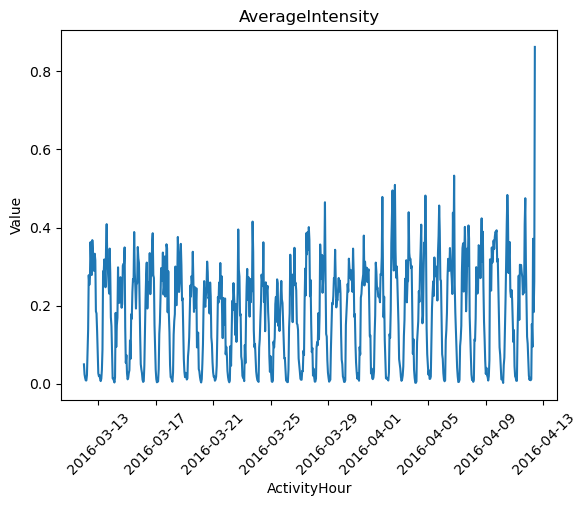

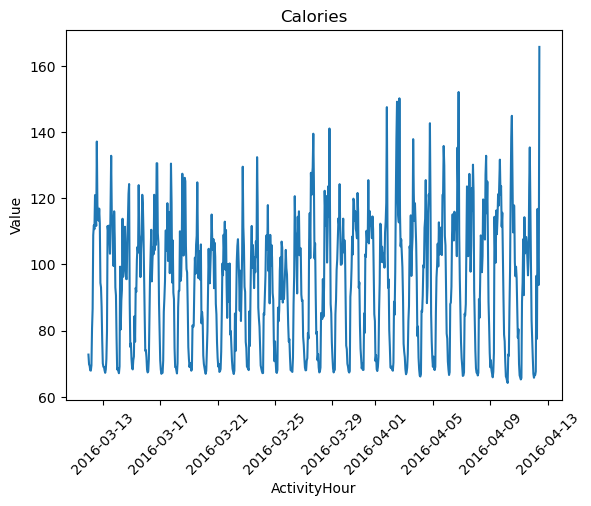

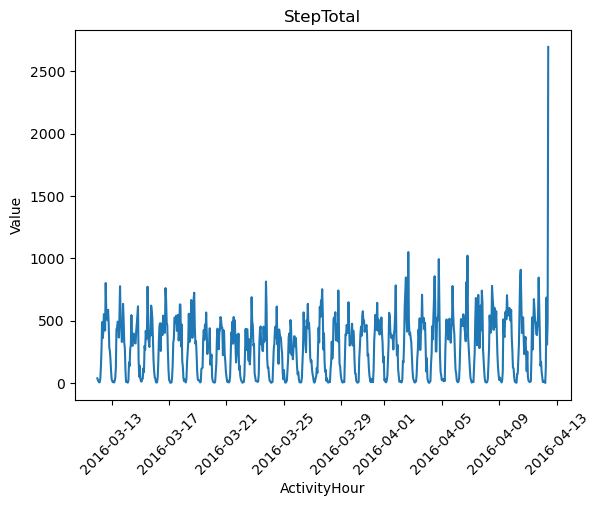

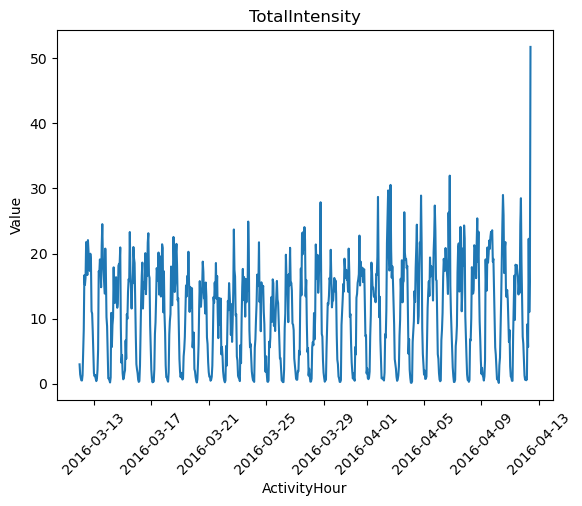

In [ ]:
for var in stats['variable'].unique():
    var_df = stats[stats['variable'] == var]
    sns.lineplot(var_df, x='ActivityHour', y='mean')
    plt.title(f"{var}")
    plt.ylabel('Value')
    plt.xticks(rotation=45)
    plt.show()

# Quantiles

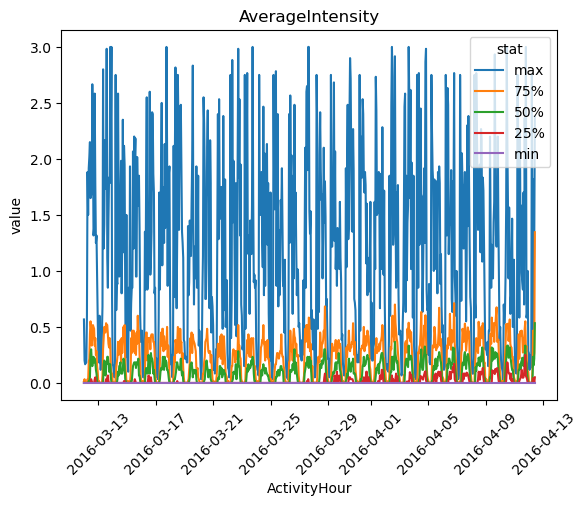

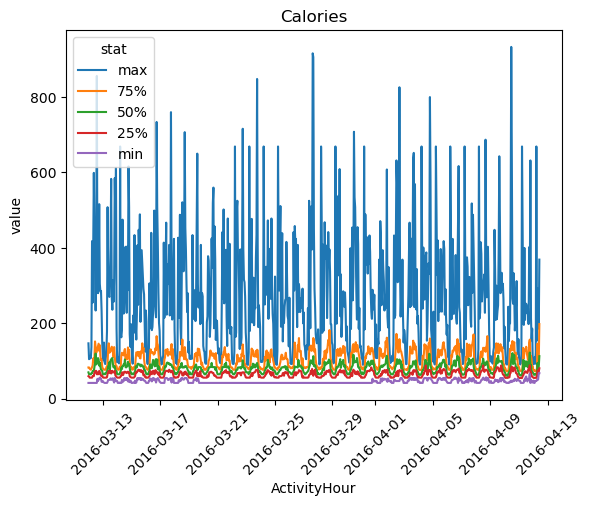

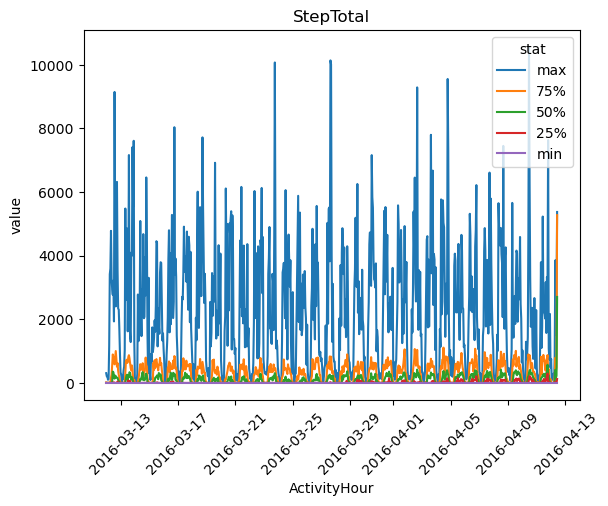

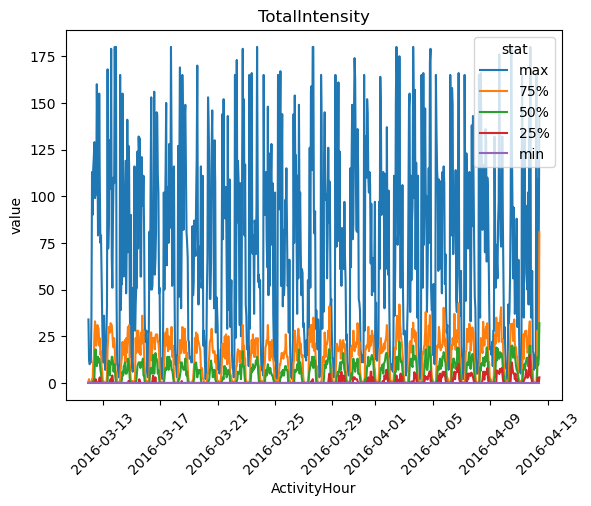

In [ ]:
for var in stats_melt['variable'].unique():
    var_df = stats_melt[stats_melt['variable'] == var]
    sns.lineplot(var_df, x='ActivityHour', y='value', hue='stat')
    plt.title(f"{var}")
    plt.xticks(rotation=45)
    plt.show()